In [ ]:
import os

%pip install -q torchvision torch

if "sam2" not in os.listdir():
    !git clone https://github.com/facebookresearch/sam2.git
    %cd sam2
    %pip install -e .
else:
    %cd sam2

%cd checkpoints

if "sam2.1_hiera_small.pt" not in os.listdir():
    !wget -O sam2.1_hiera_small.pt "https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_small.pt"

%cd ..

%cd sam2

Note: you may need to restart the kernel to use updated packages.
fatal: destination path 'sam2' already exists and is not an empty directory.
/home/gustavo/codigos/MachineLearning/deeplearning/tarefa4/sam2
Obtaining file:///home/gustavo/codigos/MachineLearning/deeplearning/tarefa4/sam2
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for SAM-2 (pyproject.toml) ... done
  Created wheel for SAM-2: filename=sam_2-1.0-0.editable-cp312-cp312-linux_x86_64.whl size=13884 sha256=cc18f1130e6a46f401487d718afb774933373d6f3eea4710a33986798659cf65
  Stored in directory: /tmp/pip-ephem-wheel-cache-xhr5kw9r/wheels/96/3b/e6/1b8ffcaecfc6298db561928b0a255c36f27cefe6dfbde7932f
Successfully built SAM-2
  Attempting uninstall: SAM-2
    Found existing installation: SAM-2 1.0
    Uninstalling SAM-2-1.0:
      Successfully uninstal

In [3]:
import torch
import torchvision

print("CUDA is available:", torch.cuda.is_available())
print("GPU memory (in GB):", round(torch.cuda.get_device_properties(0).total_memory / 1024 / 1024 / 1024, 2))

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

# Notebook de exemplo do facebook usa
if device.type == "cuda":
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

CUDA is available: True
GPU memory (in GB): 3.81
Using device: cuda


In [4]:
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

sam2_checkpoint = "../checkpoints/sam2.1_hiera_small.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_s.yaml"

sam2_model = build_sam2(model_cfg, sam2_checkpoint, device=device)

predictor = SAM2ImagePredictor(sam2_model)

In [43]:
import kagglehub
import os
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("polomarco/chest-ct-segmentation")
print("Path to dataset files:", path)

# Estrutura do dataset: images/, masks/, pretrained_model/, train.csv
images_dir = os.path.join(path, "images", "images")
masks_dir = os.path.join(path, "masks", "masks")
train_csv_path = os.path.join(path, "train.csv")

df = pd.read_csv(train_csv_path)

df.head()


Path to dataset files: /home/gustavo/.cache/kagglehub/datasets/polomarco/chest-ct-segmentation/versions/3


,ImageId,MaskId
0,ID00007637202177411956430_0.jpg,ID00007637202177411956430_mask_0.jpg
1,ID00007637202177411956430_1.jpg,ID00007637202177411956430_mask_1.jpg
2,ID00007637202177411956430_2.jpg,ID00007637202177411956430_mask_2.jpg
3,ID00007637202177411956430_3.jpg,ID00007637202177411956430_mask_3.jpg
4,ID00007637202177411956430_4.jpg,ID00007637202177411956430_mask_4.jpg


In [94]:
image_files = df['ImageId'].tolist()
image_filename = df['ImageId'][2]
image_sample_path = os.path.join(images_dir, image_filename)

mask_files = df['MaskId'].tolist()
mask_filename = df['MaskId'][2]
mask_sample_path = os.path.join(masks_dir, mask_filename)

In [ ]:
from sklearn.model_selection import train_test_split
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Split the data into two halves: one for training and one for testing
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Vectorized preparation of training and testing data lists
train_data = [
    {
        "image": os.path.join(images_dir, row["ImageId"]),
        "annotation": os.path.join(masks_dir, row["MaskId"])
    }
    for _, row in train_df.iterrows()
]

test_data = [
    {
        "image": os.path.join(images_dir, row["ImageId"]),
        "annotation": os.path.join(masks_dir, row["MaskId"])
    }
    for _, row in test_df.iterrows()
]

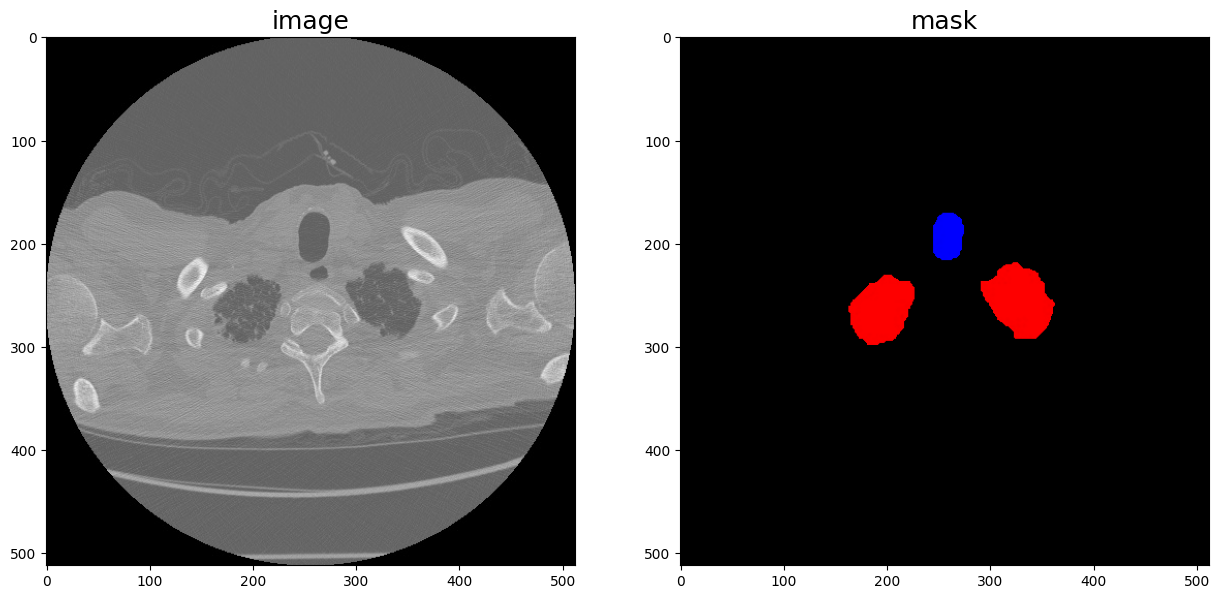

In [ ]:
def get_data(img_path, mask_path):
    img = cv2.imread(img_path)
    mask = cv2.imread(mask_path)
    mask[mask < 240] = 0  # remove artifacts

    return img, mask

one_slice_img, one_slice_mask = get_data(image_sample_path, mask_sample_path)

data_to_plot = [one_slice_img, one_slice_mask]
labels = ['image', 'mask']

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 8))

for i, ax in enumerate(axes):
    ax.imshow(data_to_plot[i])
    ax.set_title(labels[i], fontdict={"fontsize": 18})

In [140]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def get_points_from_mask(mask):
    """Obtém até num_points pontos distribuídos entre os pixels não zerados."""
    coords = np.argwhere(mask > 0)
    n_pixels = len(coords)

    num_points = max(1, n_pixels // 100)

    points = []

    if len(coords) > 0:
        # Seleciona até num_points, proporcionalmente ao número de pixels não zero
        n_select = min(8, max(1, min(num_points, n_pixels)))
        indices = np.random.choice(n_pixels, size=n_select, replace=False)
        pts = coords[indices]
        # Trocar ordem para (x, y)
        points = [[int(yx[1]), int(yx[0])] for yx in pts]

    return points

def read_batch(data, visualize_data=False):
    """Carrega e processa dados. Retorna imagem, máscaras por canal, pontos e labels."""
    ent = data[np.random.randint(len(data))]
    img, mask = get_data(ent["image"], ent["annotation"])

    # Separa por canais
    masks = [mask[:,:,0], mask[:,:,1], mask[:,:,2]]
    class_names = ['lung', 'heart', 'trachea']

    # Resize imagem e máscaras para largura ou altura máxima de 1024
    r = np.min([1024 / img.shape[1], 1024 / img.shape[0]])  # Scaling factor
    new_shape = (int(img.shape[1] * r), int(img.shape[0] * r))
    img = cv2.resize(img, new_shape)
    masks = [cv2.resize(m, new_shape, interpolation=cv2.INTER_NEAREST) for m in masks]

    points = []
    labels = []
    for i, m in enumerate(masks):
        pts = get_points_from_mask(m)
        points += pts
        labels += [i]*len(pts)


    points = np.array(points)   # shape (Total, 2)
    labels = np.array(labels)   # shape (Total,)

    # Visualização
    if visualize_data:
        fig, axs = plt.subplots(2, 3, figsize=(15, 10))

        # Imagem original
        axs[0, 0].imshow(img)
        axs[0, 0].set_title('Imagem')
        axs[0, 0].axis('off')

        # Máscara RGB
        mask_rgb = np.stack(masks, axis=-1)
        axs[0, 1].imshow(mask_rgb)
        axs[0, 1].set_title('Mask RGB')
        axs[0, 1].axis('off')

        axs[0, 2].axis('off')

        # Máscaras de cada classe
        names = ['Lung', 'Heart', 'Trachea']
        for i in range(3):
            axs[1, i].imshow(masks[i], cmap='gray')
            axs[1, i].set_title(names[i])
            axs[1, i].axis('off')

        plt.tight_layout()
        plt.show()

    masks_formatted = [np.expand_dims(m, axis=0) for m in masks]

    return img, masks_formatted, points, labels, len(masks)

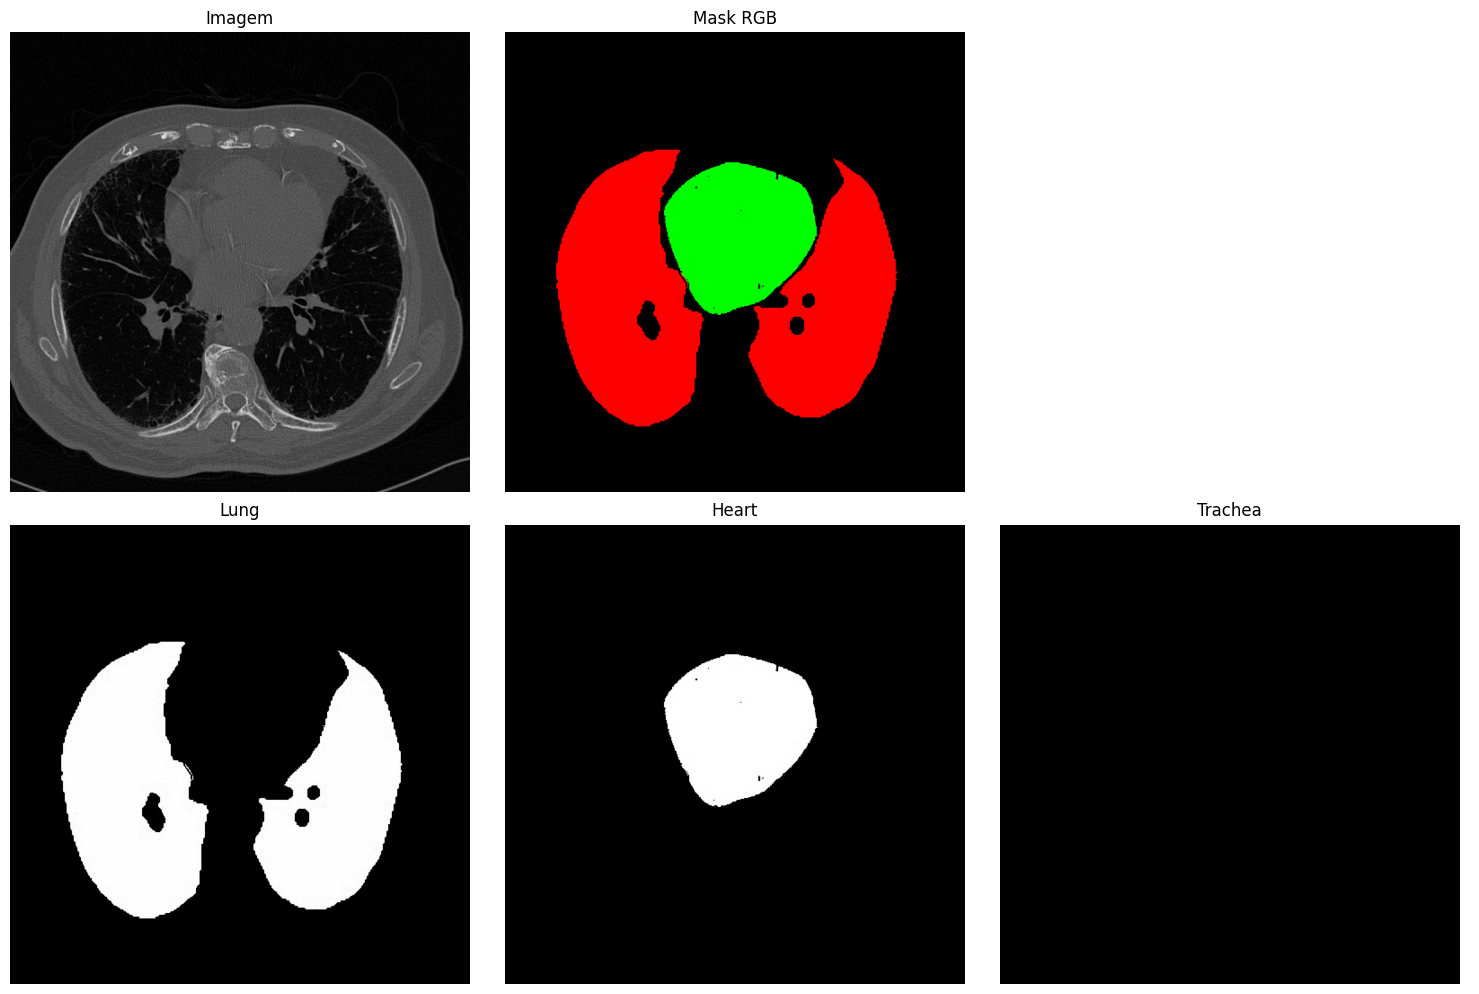

In [146]:
# Carrega e visualiza dados
img1, masks1, points1, labels1, num_classes = read_batch(train_data, visualize_data=True)

In [147]:
points1, labels1

(array([[666, 749],
        [795, 539],
        [715, 403],
        [813, 694],
        [249, 728],
        [603, 684],
        [748, 465],
        [228, 585],
        [531, 576],
        [546, 563],
        [471, 364],
        [492, 370],
        [668, 462],
        [580, 401],
        [489, 329],
        [579, 352]]),
 array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1]))

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

def show_mask(mask, ax, random_color=False, borders = True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask = mask.astype(np.uint8)
    mask_image =  mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    if borders:
        import cv2
        contours, _ = cv2.findContours(mask,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        # Try to smooth contours
        contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
        mask_image = cv2.drawContours(mask_image, contours, -1, (1, 1, 1, 0.5), thickness=2)
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))

def show_masks(image, masks, scores, point_coords=None, box_coords=None, input_labels=None, borders=True):
    # Define the number of columns and rows for the subplots
    n = len(masks)
    if n > 3:
        ncols = 3
    else:
        ncols = n
    nrows = int(np.ceil(n / ncols))
    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6*ncols, 6*nrows))

    # axs is 2D array-like even if nrows=1 or ncols=1
    axs = np.array(axs).reshape(-1)
    for i, (mask, score) in enumerate(zip(masks, scores)):
        ax = axs[i]
        ax.imshow(image)
        show_mask(mask, ax, borders=borders)
        if point_coords is not None:
            assert input_labels is not None
            show_points(point_coords, input_labels, ax)
        if box_coords is not None:
            show_box(box_coords, ax)
        if len(scores) > 1:
            ax.set_title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
        ax.axis('off')

    plt.show()

In [98]:
# Carregar a imagem de exemplo
image = Image.open(image_sample_path)
image_rgb = np.array(image.convert("RGB"))

# Definir um ponto de prompt (por exemplo, no centro da imagem)
height, width, _ = image_rgb.shape
input_point = np.array([[width // 2, height // 2]])
input_label = np.array([1])  # 1 para foreground

with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
    predictor.set_image(image_rgb)
    masks, scores, logits = predictor.predict(
        point_coords=input_point,
        point_labels=input_label,
        multimask_output=True,
    )

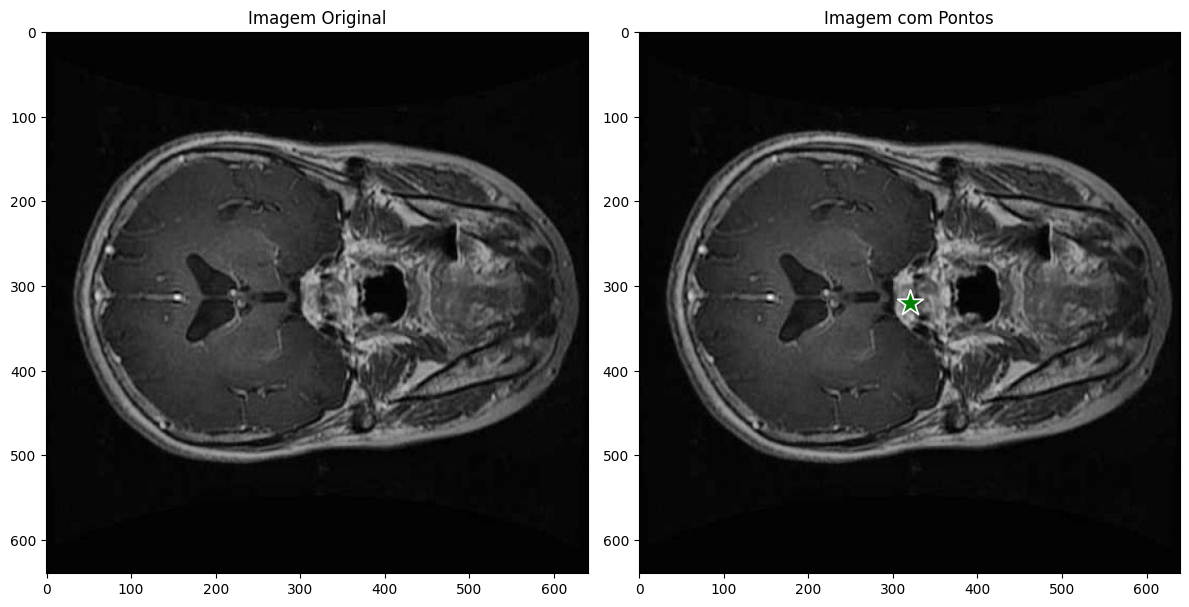

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Primeira imagem sem pontos
axs[0].imshow(image)
axs[0].set_title("Imagem Original")
axs[0].axis('on')

# Segunda imagem com pontos
axs[1].imshow(image)
show_points(input_point, input_label, axs[1])
axs[1].set_title("Imagem com Pontos")
axs[1].axis('on')

plt.tight_layout()
plt.show()

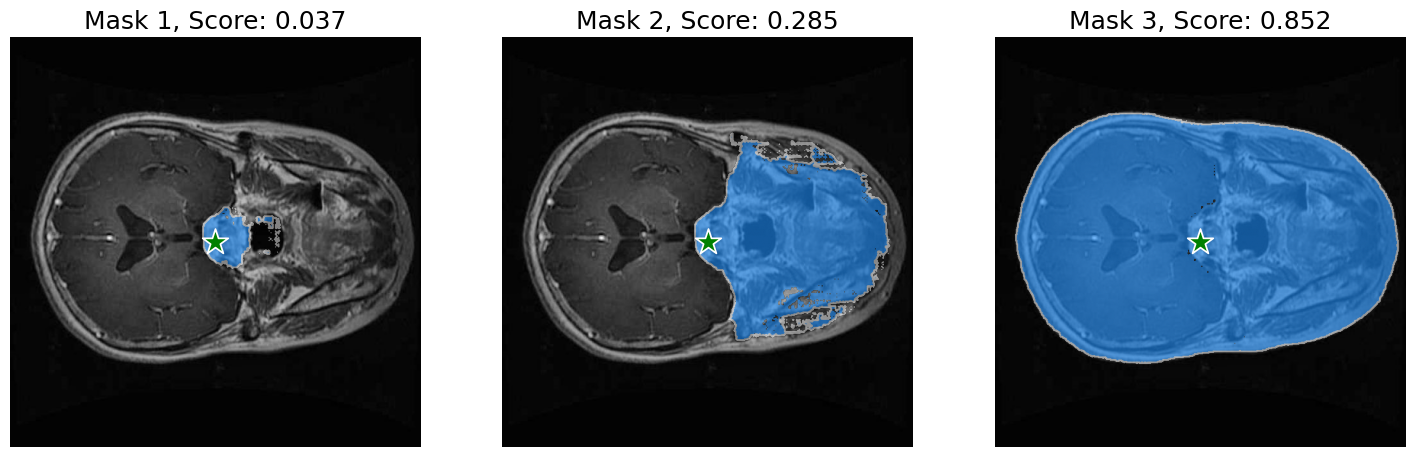

In [19]:
show_masks(image, masks, scores, point_coords=input_point, input_labels=input_label, borders=True)

NameError: name 'mask' is not defined

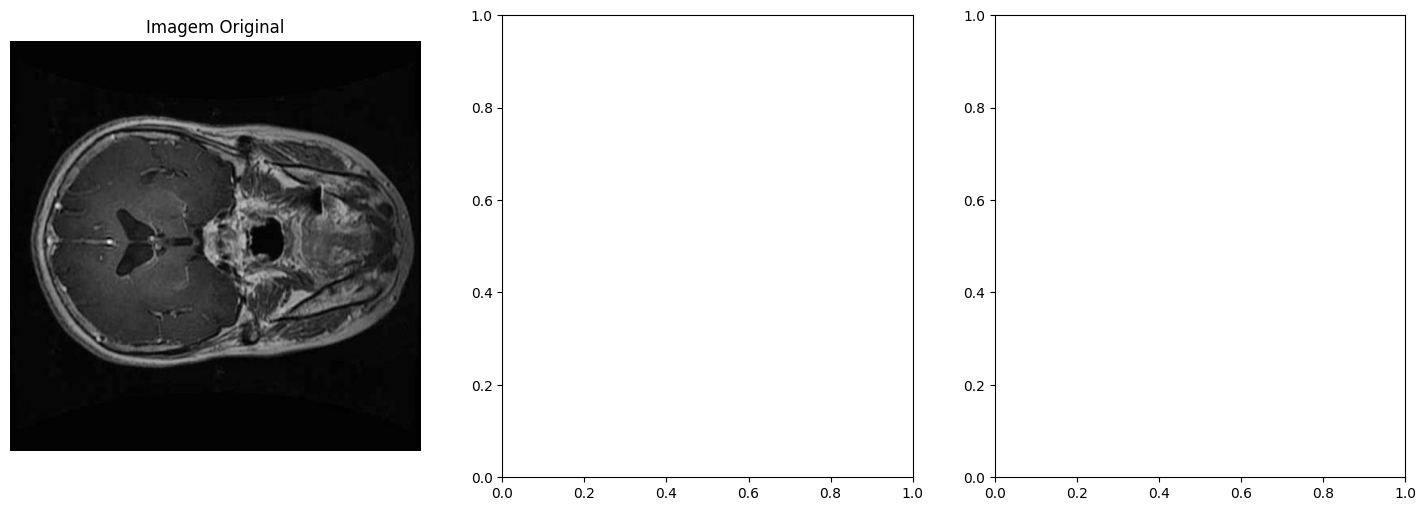

In [ ]:
# Plotar a imagem real, a máscara verdadeira (atual, como array binário) e o overlap

# Aqui assumimos que `mask` já está carregado e corresponde à imagem mostrada.
# Certifique-se de que `mask` é binário (0 e 1) e tem shape (H, W), igual ao da imagem.

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Imagem original
axs[0].imshow(image)
axs[0].set_title("Imagem Original")
axs[0].axis('off')

# Máscara real baseada no arquivo da mask, não mais no COCO
axs[1].imshow(mask, cmap='gray')
axs[1].set_title("Máscara Real")
axs[1].axis('off')

# Overlap
# Garantir que mask tem shape igual ao da imagem
if mask.shape != (image.height, image.width):
    mask_resized = np.zeros((image.height, image.width), dtype=mask.dtype)
    h = min(mask.shape[0], image.height)
    w = min(mask.shape[1], image.width)
    mask_resized[:h, :w] = mask[:h, :w]
    mask = mask_resized
# Converter imagem para array se necessário
if isinstance(image, Image.Image):
    image_arr = np.array(image.convert('RGB'))
else:
    image_arr = image

# Criar o overlay
overlay = image_arr.copy()
red_mask = np.zeros_like(image_arr)
red_mask[..., 0] = 255  # Canal vermelho
alpha = 0.5
mask_bool = mask.astype(bool)
overlay[mask_bool] = (1 - alpha) * image_arr[mask_bool] + alpha * red_mask[mask_bool]

axs[2].imshow(overlay.astype(np.uint8))
axs[2].set_title("Overlap")
axs[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import torch
import numpy as np

# Encontre os índices dos pixels da máscara (onde mask_coco > 0)
mask_indices = np.argwhere(mask_coco > 0)
if mask_indices.shape[0] == 0:
    raise ValueError("A máscara não tem nenhum pixel positivo.")

# Calcula o centroide (ponto médio) dos pixels da máscara
center_idx = np.mean(mask_indices, axis=0)  # [H, W] espaço (y,x)
center_y, center_x = center_idx.astype(int)

# Formate os prompts para o modelo SAM:
input_point = np.array([[center_x, center_y]])  # (N, 2) -> (x, y)
input_label = np.array([1])  # 1 indica foreground

with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
    predictor.set_image(image_rgb)
    masks, scores, logits = predictor.predict(
        point_coords=input_point,
        point_labels=input_label,
        multimask_output=True,
    )

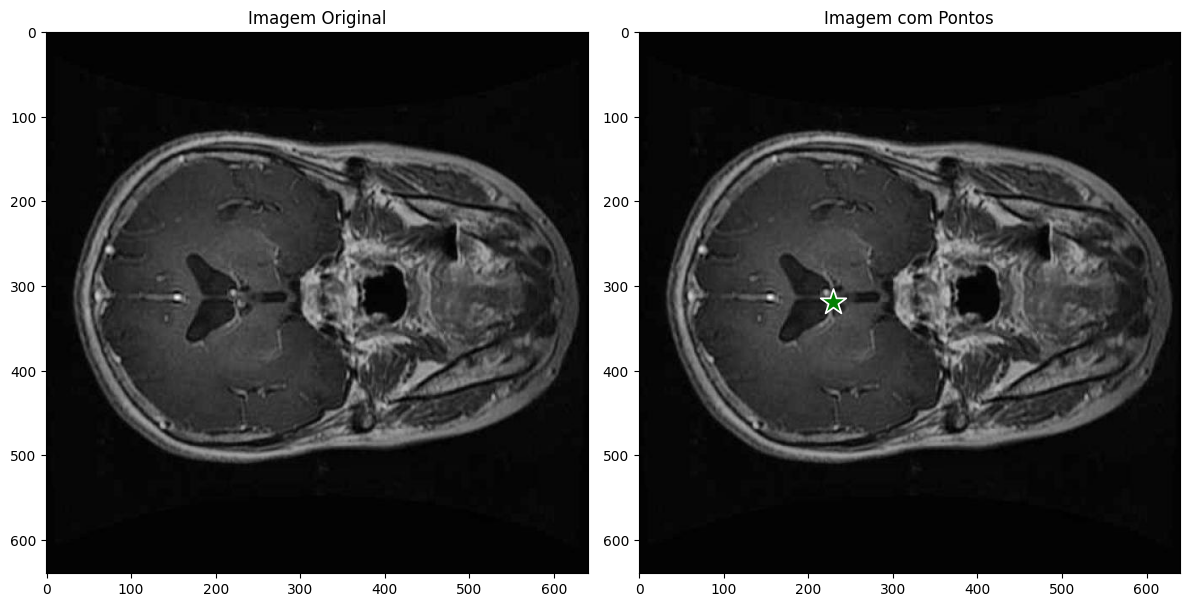

In [34]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Primeira imagem sem pontos
axs[0].imshow(image)
axs[0].set_title("Imagem Original")
axs[0].axis('on')

# Segunda imagem com pontos
axs[1].imshow(image)
show_points(input_point, input_label, axs[1])
axs[1].set_title("Imagem com Pontos")
axs[1].axis('on')

plt.tight_layout()
plt.show()

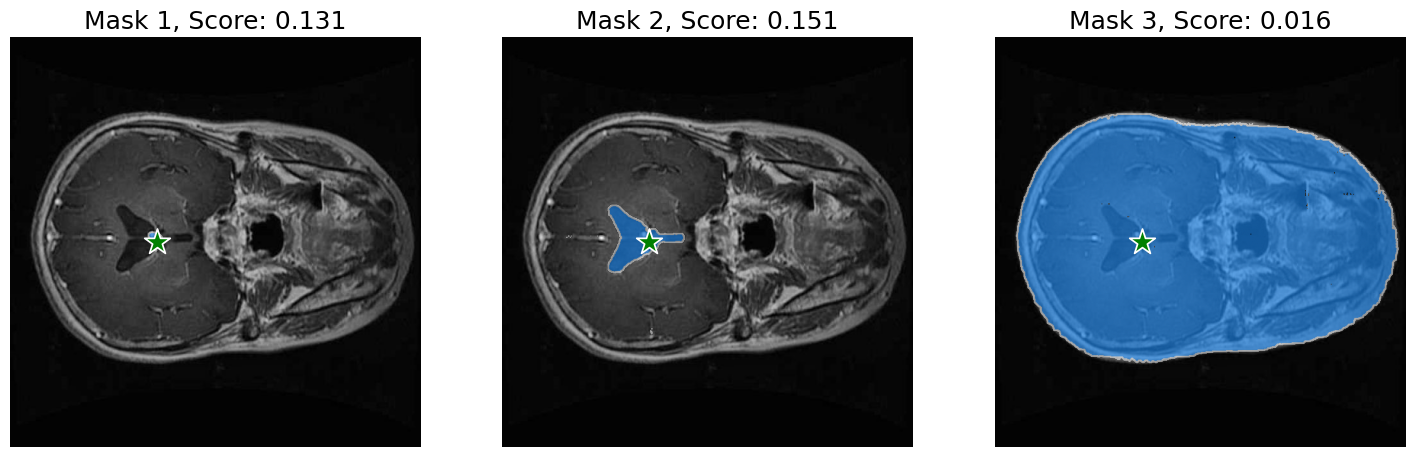

In [35]:
show_masks(image, masks, scores, point_coords=input_point, input_labels=input_label, borders=True)